In [1]:
# TO DO: set-up spark
# set-up spark (NB if Apache amend versions on download site we will need to amend path in wget command)
## NOTE that this version would make use of Hadoop if installed BUT that HDFS & Hadoop is not installed on our Colab
## (we are only using a single node (probably as a VM) so we will not be able to benefit from parallelism)
!clear
!echo welcome

!rm -f spark-3.4.[01]-bin-hadoop3.tgz*
!rm -rf spark-3.4.[01]-bin-hadoop3

!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget https://downloads.apache.org/spark/spark-3.4.3/spark-3.4.3-bin-hadoop3.tgz
!tar -xf spark-3.4.3-bin-hadoop3.tgz

!ls -alt
print("standalone Spark is now installed")

welcome
--2024-05-23 00:03:27--  https://downloads.apache.org/spark/spark-3.4.3/spark-3.4.3-bin-hadoop3.tgz
Resolving downloads.apache.org (downloads.apache.org)... 88.99.208.237, 135.181.214.104, 2a01:4f8:10a:39da::2, ...
Connecting to downloads.apache.org (downloads.apache.org)|88.99.208.237|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 388930980 (371M) [application/x-gzip]
Saving to: ‘spark-3.4.3-bin-hadoop3.tgz’

spark-3.4.3-bin-had 100%[===================>] 370.91M  22.8MB/s    in 18s     

2024-05-23 00:03:46 (20.1 MB/s) - ‘spark-3.4.3-bin-hadoop3.tgz’ saved [388930980/388930980]

total 379836
drwxr-xr-x  1 root root      4096 May 23 00:03 .
drwxr-xr-x  1 root root      4096 May 22 23:58 ..
drwxr-xr-x  1 root root      4096 May 21 13:23 sample_data
drwxr-xr-x  4 root root      4096 May 21 13:23 .config
-rw-r--r--  1 root root 388930980 Apr 15 01:30 spark-3.4.3-bin-hadoop3.tgz
drwxr-xr-x 13 1000 1000      4096 Apr 15 01:28 spark-3.4.3-bin-hadoop3
stand

In [2]:
pip install --upgrade findspark

In [3]:
# TO DO:  install findspark
# init spark (ensure SPARK_HOME set to same version as we download earlier)
!pip3 install findspark
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.4.3-bin-hadoop3"
import findspark
findspark.init()
from pyspark import SparkConf, SparkContext
# the next line gives us 'local' mode. try 'local[2]' to use 2 cores or 'master:NNNN' to run on Spark standalone cluster at port NNNN
spark_conf = SparkConf().setMaster('local[*]').setAppName('MyApp')
sc = SparkContext(conf=spark_conf)
# see what we have by examining the Spark User Interface
from pyspark.sql import *
from pyspark.sql.functions import *
SparkSession.builder.getOrCreate()
##

In [4]:
from pyspark.sql.functions import col


In [5]:
# TO DO: init spark (ensure SPARK_HOME set to same version as we download)
import os


# use 'spark' as reference (as per standard approach)
spark = SparkSession.builder.appName("bikes").getOrCreate()

In [6]:
# get bike hire file for given year from TfL open data
!wget https://cycling.data.tfl.gov.uk/usage-stats/cyclehireusagestats-2014.zip
!unzip cyclehireusagestats-2014.zip

--2024-05-23 00:05:04--  https://cycling.data.tfl.gov.uk/usage-stats/cyclehireusagestats-2014.zip
Resolving cycling.data.tfl.gov.uk (cycling.data.tfl.gov.uk)... 104.16.97.104, 104.16.98.104
Connecting to cycling.data.tfl.gov.uk (cycling.data.tfl.gov.uk)|104.16.97.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 225215129 (215M) [application/zip]
Saving to: ‘cyclehireusagestats-2014.zip’

cyclehireusagestats 100%[===================>] 214.78M   137MB/s    in 1.6s    

2024-05-23 00:05:06 (137 MB/s) - ‘cyclehireusagestats-2014.zip’ saved [225215129/225215129]

Archive:  cyclehireusagestats-2014.zip
  inflating: 1. Journey Data Extract 05Jan14-02Feb14.csv  
  inflating: 10a. Journey Data Extract 14Sep14-27Sep14.csv  
  inflating: 10b. Journey Data Extract 28Sep14-11Oct14.csv  
  inflating: 11a. Journey Data Extract 12Oct14-08Nov14.csv  
  inflating: 11b. Journey Data Extract 12Oct14-08Nov14.csv  
  inflating: 12a. Journey Data Extract 09Nov14-06Dec14.csv  
  i

In [7]:
# TO DO: read a file into a DF called "bike"import zipfile
import zipfile
from pyspark.sql import SparkSession

# Path to the ZIP file
zip_file_path = 'cyclehireusagestats-2014.zip'
extract_dir = 'cyclehire_data'

# Create a directory to extract the files
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

# Extract all the files
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("CycleHire Data Analysis") \
    .getOrCreate()

# Path to the directory containing the extracted CSV files
csv_dir = 'cyclehire_data'

# List all CSV files
csv_files = [os.path.join(csv_dir, f) for f in os.listdir(csv_dir) if f.endswith('.csv')]

# Read and combine all CSV files into a single DataFrame
bike = spark.read.csv(csv_files, header=True, inferSchema=True)

# Optional: Show the combined DataFrame schema and first few rows
bike.printSchema()
bike.show(5)

# Optional: Save the combined DataFrame
bike.write.csv('combined_cyclehire_data.csv', header=True)

root
 |-- Rental Id: string (nullable = true)
 |-- Duration: string (nullable = true)
 |-- Bike Id: string (nullable = true)
 |-- End Date: string (nullable = true)
 |-- EndStation Id: string (nullable = true)
 |-- EndStation Name: string (nullable = true)
 |-- Start Date: string (nullable = true)
 |-- StartStation Id: string (nullable = true)
 |-- StartStation Name: string (nullable = true)

+---------+--------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+
|Rental Id|Duration|Bike Id|        End Date|EndStation Id|     EndStation Name|      Start Date|StartStation Id|   StartStation Name|
+---------+--------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+
| 34263367|    1080|   9076|24/06/2014 00:57|          695|Islington Green, ...|24/06/2014 00:39|            311|Foley Street, Fit...|
| 34603487|     660|   6328|03/07/2014 11:51|          695|Islin

In [8]:
# see how many entries (rows) in data before cleaning
numRows = bike.count()
print("there are ",numRows," rows")

there are  11481596  rows


In [9]:
# recall... before cleaning
bike.agg({"Duration": "min"}).show()
bike.agg({"Duration": "mean"}).show()
bike.agg({"Duration": "max"}).show()
bike.agg({"Duration": "skewness"}).show()

+-------------+
|min(Duration)|
+-------------+
|        -1020|
+-------------+

+-----------------+
|    avg(Duration)|
+-----------------+
|1466.081447242822|
+-----------------+

+-------------+
|max(Duration)|
+-------------+
|        99900|
+-------------+

+------------------+
|skewness(Duration)|
+------------------+
| 83.09423732692431|
+------------------+



In [13]:
duration_column = bike.select("Duration")
summary_df = duration_column.summary()
summary_df.show()

+-------+------------------+
|summary|          Duration|
+-------+------------------+
|  count|          10242483|
|   mean| 1466.081447242822|
| stddev|12946.838147599005|
|    min|             -1020|
|    25%|             480.0|
|    50%|             840.0|
|    75%|            1320.0|
|    max|             99900|
+-------+------------------+



In [14]:
# Step 2: Data Cleaning
# Assuming 'Duration' is the column representing ride duration
# Assuming 'StartStation' is the column representing the starting station
bike_cleaned = bike.dropna()  # Drop rows with missing values
bike=bike.dropDuplicates() #Drop Duplicates
bike_cleaned = bike_cleaned.withColumn("Duration", bike_cleaned["Duration"].cast("int"))  # Convert duration to integer if necessary


In [15]:
# Filter out records with Duration > 9000 seconds or Duration <= 0 seconds
bike_cleaned = bike_cleaned.filter((bike_cleaned["Duration"] <= 9000) & (bike_cleaned["Duration"] > 0))

# Total number of rides after filtering
total = bike_cleaned.count()

# Number of rides with duration less than 9000 seconds (2.5 hours)
numExceed = bike_cleaned.filter(bike_cleaned["Duration"] < 9000).count()

# Calculate the percentage
percentage_under_2_5_hours = (numExceed * 100) / total

print("Of all rides, percentage under 2.5 hours:", percentage_under_2_5_hours)



Of all rides, percentage under 2.5 hours: 99.99102138776551


In [16]:
#look at the numbers
bike_cleaned.count()

10124059

In [17]:
duration_column = bike_cleaned.select("Duration")
summary_df = duration_column.summary()
summary_df.show()

+-------+------------------+
|summary|          Duration|
+-------+------------------+
|  count|          10124059|
|   mean|1073.9097628727766|
| stddev|1001.3147336849778|
|    min|                60|
|    25%|               480|
|    50%|               840|
|    75%|              1320|
|    max|              9000|
+-------+------------------+



In [ ]:
bike_cleaned.agg({"Duration": "min"}).show()
bike_cleaned.agg({"Duration": "mean"}).show()
bike_cleaned.agg({"Duration": "max"}).show()
bike_cleaned.agg({"Duration": "skewness"}).show()

+-------------+
|min(Duration)|
+-------------+
|           60|
+-------------+

+------------------+
|     avg(Duration)|
+------------------+
|1073.9097628727766|
+------------------+

+-------------+
|max(Duration)|
+-------------+
|         9000|
+-------------+

+------------------+
|skewness(Duration)|
+------------------+
| 3.296742751570676|
+------------------+



In [ ]:

# Convert duration from seconds to minutes
bike_cleaned = bike_cleaned.withColumn("Duration_minutes", col("Duration") / 60)

# Show the updated DataFrame
bike_cleaned.show()


+---------+--------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+----------------+
|Rental Id|Duration|Bike Id|        End Date|EndStation Id|     EndStation Name|      Start Date|StartStation Id|   StartStation Name|Duration_minutes|
+---------+--------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+----------------+
| 34263367|    1080|   9076|24/06/2014 00:57|          695|Islington Green, ...|24/06/2014 00:39|            311|Foley Street, Fit...|            18.0|
| 34603487|     660|   6328|03/07/2014 11:51|          695|Islington Green, ...|03/07/2014 11:40|             22|Northington Stree...|            11.0|
| 34689078|     120|   2006|05/07/2014 15:09|          357|Howland Street, F...|05/07/2014 15:07|            311|Foley Street, Fit...|             2.0|
| 34724273|    1260|   7904|06/07/2014 16:35|          695|Islington Green, ...|06/07/20

In [ ]:
# Drop the original "Duration" column
bike_cleaned = bike_cleaned.drop("Duration")

# Show the updated DataFrame
bike_cleaned.show(3)



+---------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+----------------+
|Rental Id|Bike Id|        End Date|EndStation Id|     EndStation Name|      Start Date|StartStation Id|   StartStation Name|Duration_minutes|
+---------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+----------------+
| 34263367|   9076|24/06/2014 00:57|          695|Islington Green, ...|24/06/2014 00:39|            311|Foley Street, Fit...|            18.0|
| 34603487|   6328|03/07/2014 11:51|          695|Islington Green, ...|03/07/2014 11:40|             22|Northington Stree...|            11.0|
| 34689078|   2006|05/07/2014 15:09|          357|Howland Street, F...|05/07/2014 15:07|            311|Foley Street, Fit...|             2.0|
+---------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+----------------+

In [ ]:
#change the duration _minutes to int type
bike_cleaned = bike_cleaned.withColumn("Duration_minutes", bike_cleaned["Duration_minutes"].cast("int"))

In [ ]:
#filtering rides with duration less than 1 minute
bike_cleaned = bike_cleaned.filter(col("Duration_minutes") > 0)



In [ ]:
bike_cleaned.agg({"Duration_minutes": "min"}).show()
bike_cleaned.agg({"Duration_minutes": "mean"}).show()
bike_cleaned.agg({"Duration_minutes": "max"}).show()
bike_cleaned.agg({"Duration_minutes": "skewness"}).show()

+---------------------+
|min(Duration_minutes)|
+---------------------+
|                    1|
+---------------------+

+---------------------+
|avg(Duration_minutes)|
+---------------------+
|    17.89849604787961|
+---------------------+

+---------------------+
|max(Duration_minutes)|
+---------------------+
|                  150|
+---------------------+

+--------------------------+
|skewness(Duration_minutes)|
+--------------------------+
|        3.2967427515706498|
+--------------------------+



In [ ]:
# creating a dataframe baylis_rides from original data set
baylis_rides = bike_cleaned.filter(col("StartStation Name").like("%Baylis Road, Waterloo%"))
baylis_rides.show()

+---------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+----------------+
|Rental Id|Bike Id|        End Date|EndStation Id|     EndStation Name|      Start Date|StartStation Id|   StartStation Name|Duration_minutes|
+---------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+----------------+
| 34335942|   7213|25/06/2014 18:59|          199|Great Tower Stree...|25/06/2014 18:49|            272|Baylis Road, Wate...|              10|
| 34292680|  11506|24/06/2014 18:12|          199|Great Tower Stree...|24/06/2014 18:03|            272|Baylis Road, Wate...|               9|
| 34251992|   1845|23/06/2014 17:58|          199|Great Tower Stree...|23/06/2014 17:48|            272|Baylis Road, Wate...|              10|
| 34618956|   8070|03/07/2014 17:59|          199|Great Tower Stree...|03/07/2014 17:47|            272|Baylis Road, Wate...|              12|

In [ ]:
baylis_rides.orderBy(col("Duration_minutes").desc()).show()

+---------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+----------------+
|Rental Id|Bike Id|        End Date|EndStation Id|     EndStation Name|      Start Date|StartStation Id|   StartStation Name|Duration_minutes|
+---------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+----------------+
| 34133808|   7175|20/06/2014 23:48|          252|Jubilee Gardens, ...|20/06/2014 21:18|            272|Baylis Road, Wate...|             150|
| 34133804|   2312|20/06/2014 23:48|          252|Jubilee Gardens, ...|20/06/2014 21:18|            272|Baylis Road, Wate...|             150|
| 34133837|   2085|20/06/2014 23:48|          334|Concert Hall Appr...|20/06/2014 21:19|            272|Baylis Road, Wate...|             149|
| 34133833|   7152|20/06/2014 23:48|          252|Jubilee Gardens, ...|20/06/2014 21:19|            272|Baylis Road, Wate...|             149|

In [ ]:
# calculating ride counts
baylis_rides_count = baylis_rides.count()
print("Number of rides starting from Baylis Road Waterloo Station:", baylis_rides_count)


Number of rides starting from Baylis Road Waterloo Station: 27064


In [ ]:
#splitting data into other rides and baylis road rides
other_rides = bike_cleaned.filter(~col("StartStation Name").like("%Baylis Road, Waterloo%"))


In [ ]:
other_rides.count()

10096995

In [ ]:
other_rides.show(4)

+---------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+----------------+
|Rental Id|Bike Id|        End Date|EndStation Id|     EndStation Name|      Start Date|StartStation Id|   StartStation Name|Duration_minutes|
+---------+-------+----------------+-------------+--------------------+----------------+---------------+--------------------+----------------+
| 34263367|   9076|24/06/2014 00:57|          695|Islington Green, ...|24/06/2014 00:39|            311|Foley Street, Fit...|              18|
| 34603487|   6328|03/07/2014 11:51|          695|Islington Green, ...|03/07/2014 11:40|             22|Northington Stree...|              11|
| 34689078|   2006|05/07/2014 15:09|          357|Howland Street, F...|05/07/2014 15:07|            311|Foley Street, Fit...|               2|
| 34724273|   7904|06/07/2014 16:35|          695|Islington Green, ...|06/07/2014 16:14|            311|Foley Street, Fit...|              21|

In [ ]:
# Step 3: Data Analysis
# Calculate average duration for rides starting from Baylis Road Waterloo Station
baylis_rides = bike_cleaned.filter(col("StartStation Name").like("%Baylis Road, Waterloo%"))
baylis_avg_duration=baylis_rides.agg({"Duration_minutes": "avg"}).collect()[0][0]
print("Average duration for rides starting from Baylis Road, Waterloo Station:", baylis_avg_duration)


Average duration for rides starting from Baylis Road, Waterloo Station: 13.754655631096659


In [ ]:
# Calculate average duration for rides starting from other stations
other_rides = bike_cleaned.filter(~col("StartStation Name").like("%Baylis Road, Waterloo%"))
other_avg_duration = other_rides.agg({"Duration_minutes": "avg"}).collect()[0][0]
print("Average duration for rides starting from other stations:", other_avg_duration)

Average duration for rides starting from other stations: 17.909603203725464


In [ ]:
#forming a list of duration list for hypothesis tesiting
baylis_duration_list = baylis_rides.select("Duration_minutes").rdd.flatMap(lambda x: x).collect()


In [ ]:
other_duration_list = other_rides.select("Duration_minutes").rdd.flatMap(lambda x: x).collect()


In [ ]:
from scipy import stats

# Perform t-test
t_stat, p_value = stats.ttest_ind(baylis_duration_list, other_duration_list, equal_var=False)
one_tailed_p_value = p_value / 2  # Convert to one-tailed p-value

# Print the results
print("T-statistic:", t_stat)
print("P-value (two-tailed):", p_value)
print("One-tailed P-value:", one_tailed_p_value)

# Hypothesis Testing Decision
if (t_stat < 0) and (one_tailed_p_value < 0.05):
    print("Reject the null hypothesis. The average duration of rides at Baylis Road Waterloo Station is significantly less than other stations.")
else:
    print("Fail to reject the null hypothesis. No significant difference or opposite direction.")


T-statistic: -55.581391069815865
P-value (two-tailed): 0.0
One-tailed P-value: 0.0
Reject the null hypothesis. The average duration of rides at Baylis Road Waterloo Station is significantly less than other stations.


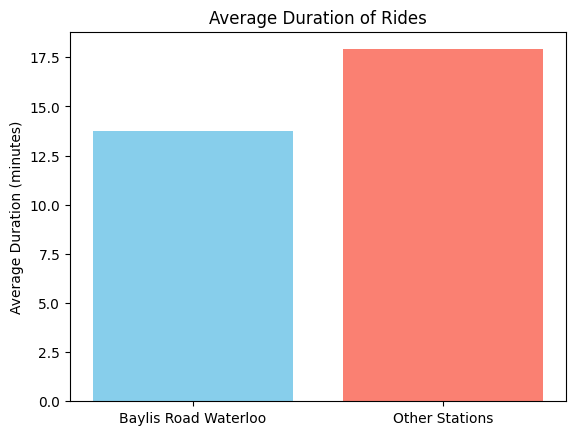

In [ ]:
# Plot the bar plot
import matplotlib.pyplot as plt
labels = ['Baylis Road Waterloo', 'Other Stations']
avg_durations = [baylis_avg_duration, other_avg_duration]

plt.bar(labels, avg_durations, color=['skyblue', 'salmon'])
plt.ylabel('Average Duration (minutes)')
plt.title('Average Duration of Rides')
plt.show()

In [ ]:
from pyspark.sql.functions import col

# Check for missing values
missing_duration_count = bike_cleaned.filter(col("Duration_minutes").isNull()).count()
print("Number of missing values in duration column:", missing_duration_count)

# Check data format
data_format_check = bike_cleaned.select("Duration_minutes").dtypes
print("Data format of duration column:", data_format_check)

# Check summary statistics for duration column
summary_stats = bike_cleaned.describe("Duration_minutes").show()





Number of missing values in duration column: 0
Data format of duration column: [('Duration_minutes', 'int')]
+-------+------------------+
|summary|  Duration_minutes|
+-------+------------------+
|  count|          10124059|
|   mean| 17.89849604787961|
| stddev|16.688578894749604|
|    min|                 1|
|    max|               150|
+-------+------------------+



Py4JJavaError: An error occurred while calling o239.collectToPython.
: java.lang.OutOfMemoryError: Java heap space
	at org.apache.spark.sql.execution.SparkPlan$$anon$1._next(SparkPlan.scala:417)
	at org.apache.spark.sql.execution.SparkPlan$$anon$1.getNext(SparkPlan.scala:426)
	at org.apache.spark.sql.execution.SparkPlan$$anon$1.getNext(SparkPlan.scala:412)
	at org.apache.spark.util.NextIterator.hasNext(NextIterator.scala:73)
	at scala.collection.Iterator.foreach(Iterator.scala:943)
	at scala.collection.Iterator.foreach$(Iterator.scala:943)
	at org.apache.spark.util.NextIterator.foreach(NextIterator.scala:21)
	at org.apache.spark.sql.execution.SparkPlan.$anonfun$executeCollect$1(SparkPlan.scala:449)
	at org.apache.spark.sql.execution.SparkPlan.$anonfun$executeCollect$1$adapted(SparkPlan.scala:448)
	at org.apache.spark.sql.execution.SparkPlan$$Lambda$3517/1326889048.apply(Unknown Source)
	at scala.collection.IndexedSeqOptimized.foreach(IndexedSeqOptimized.scala:36)
	at scala.collection.I